# CYP3A4 Inhibition Predictor
**Score** = 0.5 × (1 − min(NRMSE, 1)) + 0.5 × Pearson r

Pipeline: Morgan FP + MACCS + RDKit descriptors + ChemBERTa → XGBoost/LightGBM/CatBoost ensemble with scaffold-based CV

## 0. Imports & Config

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# RDKit
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, Descriptors, MACCSkeys
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.ML.Descriptors import MoleculeDescriptors
RDLogger.DisableLog('rdApp.*')

# Models
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# sklearn
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer

# Transformer
import torch
from transformers import AutoTokenizer, AutoModel

# Paths
BASE_DIR  = Path('.')
DATA_DIR  = BASE_DIR / 'DATA'
FEAT_DIR  = BASE_DIR / 'features'
MODEL_DIR = BASE_DIR / 'models'
SUB_DIR   = BASE_DIR / 'submissions'

for d in [FEAT_DIR, MODEL_DIR, SUB_DIR]:
    d.mkdir(exist_ok=True)

SEED   = 42
N_JOBS = os.cpu_count()  # use all available cores
np.random.seed(SEED)
torch.set_num_threads(N_JOBS)
print('Setup complete.')

Setup complete.


## 1. Load Data

In [2]:
train_df = pd.read_csv(DATA_DIR / 'train.csv')
test_df  = pd.read_csv(DATA_DIR / 'test.csv')
sample_sub = pd.read_csv(DATA_DIR / 'sample_submission.csv')

print(f'Train: {train_df.shape}  |  Test: {test_df.shape}')
print(f'Inhibition range: [{train_df.Inhibition.min():.1f}, {train_df.Inhibition.max():.1f}]')
train_df.head()

Train: (1681, 3)  |  Test: (100, 2)
Inhibition range: [0.0, 99.4]


,ID,Canonical_Smiles,Inhibition
0,TRAIN_0000,Cl.OC1(Cc2cccc(Br)c2)CCNCC1,12.50
1,TRAIN_0001,Brc1ccc2OCCc3ccnc1c23,4.45
2,TRAIN_0002,CC1(CO)CC(=NO1)c2cc(c(F)cc2Cl)[N+](=O)[O-],4.92
3,TRAIN_0003,Fc1ccc2nc(Nc3cccc(COc4cccc(c4)C(=O)N5CCOCC5)c3...,71.50
4,TRAIN_0004,CC(C)CC(=O)C1=C(Nc2c(Cl)ccc(Cl)c2C1=O)S(=O)C,18.30


## 2. EDA

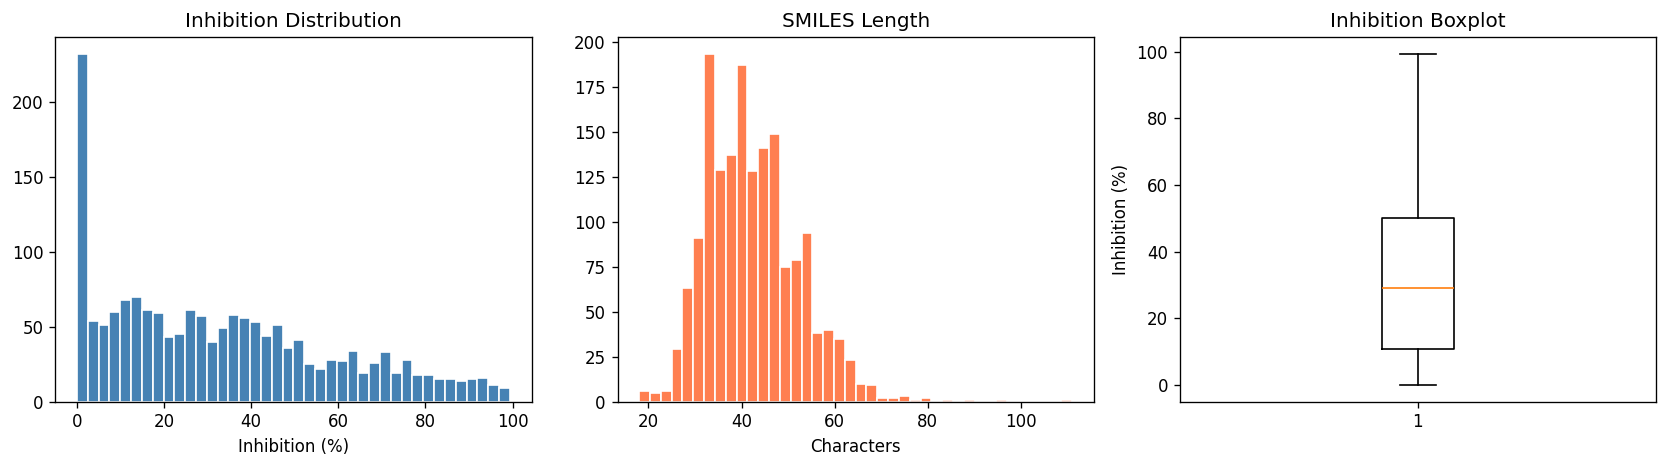

count    1681.000000
mean       33.221831
std        26.405830
min         0.000000
25%        10.900000
50%        29.000000
75%        50.200000
max        99.381547
Name: Inhibition, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(train_df['Inhibition'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Inhibition Distribution')
axes[0].set_xlabel('Inhibition (%)')

smiles_len = train_df['Canonical_Smiles'].str.len()
axes[1].hist(smiles_len, bins=40, color='coral', edgecolor='white')
axes[1].set_title('SMILES Length')
axes[1].set_xlabel('Characters')

axes[2].boxplot(train_df['Inhibition'], vert=True)
axes[2].set_title('Inhibition Boxplot')
axes[2].set_ylabel('Inhibition (%)')

plt.tight_layout()
plt.show()

print(train_df['Inhibition'].describe())

## 3. Featurization

In [ ]:
# ----- Classical fingerprints & descriptors -----

def get_morgan_fp(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(n_bits)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    return np.array(fp)

def get_maccs_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(167)
    fp = MACCSkeys.GenMACCSKeys(mol)
    return np.array(fp)

_SKIP_DESCS = {'Ipc'}  # overflows on certain molecules
_desc_names = [d[0] for d in Descriptors.descList if d[0] not in _SKIP_DESCS]
_calc = MoleculeDescriptors.MolecularDescriptorCalculator(_desc_names)

def get_rdkit_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.array([np.nan] * len(_desc_names))
    try:
        desc = np.array(_calc.CalcDescriptors(mol), dtype=float)
    except Exception:
        desc = np.array([np.nan] * len(_desc_names))
    return desc

def compute_classical_features(smiles_list, tag=''):
    """Return (morgan, maccs, rdkit_desc) arrays."""
    print(f'  Computing Morgan FP {tag}...')
    morgan = np.vstack([get_morgan_fp(s) for s in smiles_list])
    print(f'  Computing MACCS {tag}...')
    maccs  = np.vstack([get_maccs_fp(s) for s in smiles_list])
    print(f'  Computing RDKit descriptors {tag}...')
    rdkit  = np.vstack([get_rdkit_descriptors(s) for s in smiles_list])
    return morgan, maccs, rdkit

print('Featurization functions defined.')

In [ ]:
# ----- ChemBERTa embeddings -----

CHEMBERTA_MODEL = 'seyonec/ChemBERTa-zinc-base-v1'

print(f'Loading ChemBERTa: {CHEMBERTA_MODEL}')
_cb_tokenizer = AutoTokenizer.from_pretrained(CHEMBERTA_MODEL)
_cb_model     = AutoModel.from_pretrained(CHEMBERTA_MODEL)
_cb_model.eval()
print('ChemBERTa loaded.')

def get_chemberta_embedding(smiles):
    inputs = _cb_tokenizer(smiles, return_tensors='pt', truncation=True, max_length=128)
    with torch.no_grad():
        outputs = _cb_model(**inputs)
    return outputs.last_hidden_state[:, 0, :].squeeze().numpy()  # (768,)

def compute_chemberta_features(smiles_list, tag='', batch_size=32):
    embs = []
    total = len(smiles_list)
    for i in range(0, total, batch_size):
        batch = smiles_list[i:i+batch_size]
        for s in batch:
            embs.append(get_chemberta_embedding(s))
        if (i // batch_size) % 5 == 0:
            print(f'  ChemBERTa {tag}: {min(i+batch_size, total)}/{total}')
    return np.vstack(embs)

print('ChemBERTa function defined.')

Loading ChemBERTa: seyonec/ChemBERTa-zinc-base-v1
ChemBERTa loaded.
ChemBERTa function defined.


: 

In [ ]:
import gc

train_smiles = train_df['Canonical_Smiles'].tolist()
test_smiles  = test_df['Canonical_Smiles'].tolist()

def _compute_and_save(path, fn, smiles, label):
    if path.exists():
        print(f'  [cache] {path.name}')
        return
    print(f'  Computing {label}...')
    arr = np.vstack([fn(s) for s in smiles])
    np.save(path, arr)
    print(f'  [saved] {path.name}  shape={arr.shape}')
    del arr
    gc.collect()

for tag, smiles, prefix in [('train', train_smiles, 'tr'), ('test', test_smiles, 'te')]:
    print(f'\n=== {tag} classical features ===')
    _compute_and_save(FEAT_DIR / f'{prefix}_morgan.npy', get_morgan_fp,          smiles, f'Morgan FP ({tag})')
    _compute_and_save(FEAT_DIR / f'{prefix}_maccs.npy',  get_maccs_fp,           smiles, f'MACCS ({tag})')
    _compute_and_save(FEAT_DIR / f'{prefix}_rdkit.npy',  get_rdkit_descriptors,  smiles, f'RDKit desc ({tag})')

print('\n=== ChemBERTa features ===')
torch.set_num_threads(2)  # reduce thread count during inference to lower peak RAM
try:
    for tag, smiles, prefix in [('train', train_smiles, 'tr'), ('test', test_smiles, 'te')]:
        final_path = FEAT_DIR / f'{prefix}_chemberta.npy'
        ckpt_path  = FEAT_DIR / f'{prefix}_chemberta.ckpt.npy'

        if final_path.exists():
            print(f'  [cache] {final_path.name}')
            continue

        # Resume from checkpoint if a previous run crashed mid-way
        if ckpt_path.exists():
            done = np.load(ckpt_path)
            start = len(done)
            embs  = list(done)
            print(f'  Resuming ChemBERTa {tag} from {start}/{len(smiles)}')
        else:
            embs  = []
            start = 0

        for i in range(start, len(smiles)):
            embs.append(get_chemberta_embedding(smiles[i]))
            if (i + 1) % 200 == 0 or i == len(smiles) - 1:
                np.save(ckpt_path, np.vstack(embs))
                print(f'  ChemBERTa {tag}: {i+1}/{len(smiles)}')

        arr = np.vstack(embs)
        np.save(final_path, arr)
        ckpt_path.unlink(missing_ok=True)
        print(f'  [saved] {final_path.name}  shape={arr.shape}')
        del arr, embs
        gc.collect()
finally:
    torch.set_num_threads(N_JOBS)  # restore

# Load all features from disk for assembly
print('\n=== Loading features from disk ===')
tr_morgan    = np.load(FEAT_DIR / 'tr_morgan.npy')
tr_maccs     = np.load(FEAT_DIR / 'tr_maccs.npy')
tr_rdkit     = np.load(FEAT_DIR / 'tr_rdkit.npy')
te_morgan    = np.load(FEAT_DIR / 'te_morgan.npy')
te_maccs     = np.load(FEAT_DIR / 'te_maccs.npy')
te_rdkit     = np.load(FEAT_DIR / 'te_rdkit.npy')
tr_chemberta = np.load(FEAT_DIR / 'tr_chemberta.npy')
te_chemberta = np.load(FEAT_DIR / 'te_chemberta.npy')
print('All features ready.')

# Free ChemBERTa model — no longer needed after feature extraction
del _cb_model, _cb_tokenizer
gc.collect()


In [ ]:
# ----- Assemble final feature matrices -----

imputer = SimpleImputer(strategy='median')
tr_rdkit_imp = imputer.fit_transform(tr_rdkit)
te_rdkit_imp = imputer.transform(te_rdkit)
del tr_rdkit, te_rdkit
gc.collect()

vt = VarianceThreshold(threshold=0.0)
tr_rdkit_filt = vt.fit_transform(tr_rdkit_imp)
te_rdkit_filt = vt.transform(te_rdkit_imp)
del tr_rdkit_imp, te_rdkit_imp
gc.collect()

X_train = np.concatenate([tr_morgan, tr_maccs, tr_rdkit_filt, tr_chemberta], axis=1)
X_test  = np.concatenate([te_morgan, te_maccs, te_rdkit_filt, te_chemberta], axis=1)
y_train = train_df['Inhibition'].values.astype(float)

X_train_cls = np.concatenate([tr_morgan, tr_maccs, tr_rdkit_filt], axis=1)
X_test_cls  = np.concatenate([te_morgan, te_maccs, te_rdkit_filt], axis=1)

del tr_morgan, tr_maccs, tr_rdkit_filt, tr_chemberta
del te_morgan, te_maccs, te_rdkit_filt, te_chemberta
gc.collect()

print(f'X_train (full):      {X_train.shape}')
print(f'X_train (classical): {X_train_cls.shape}')
print(f'X_test  (full):      {X_test.shape}')


## 4. Scaffold-Based CV Setup

In [ ]:
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return smiles
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)

print('Computing Murcko scaffolds...')
train_df['scaffold'] = train_df['Canonical_Smiles'].apply(get_scaffold)
n_unique = train_df['scaffold'].nunique()
print(f'Unique scaffolds: {n_unique} / {len(train_df)} molecules')

gkf   = GroupKFold(n_splits=5)
folds = list(gkf.split(X_train, y_train, groups=train_df['scaffold']))
print(f'Folds: {len(folds)}')
for i, (tr, vl) in enumerate(folds):
    print(f'  Fold {i+1}: train={len(tr)}, val={len(vl)}')

In [ ]:
def competition_score(y_true, y_pred):
    rmse  = np.sqrt(np.mean((y_true - y_pred) ** 2))
    nrmse = rmse / (np.max(y_true) - np.min(y_true))
    A     = min(nrmse, 1.0)
    if np.std(y_pred) < 1e-9:          # constant prediction → pearsonr undefined
        return 0.5 * (1 - A)
    r, _ = pearsonr(y_true, y_pred)
    r    = 0.0 if np.isnan(r) else float(r)
    B    = float(np.clip(r, 0.0, 1.0))
    return 0.5 * (1 - A) + 0.5 * B


## 5. XGBoost Baseline (Scaffold CV)

In [ ]:
def run_xgb_cv(X, X_te, y, folds, params, tag='XGB'):
    oof_preds  = np.zeros(len(y))
    test_preds = np.zeros(len(X_te))
    fold_scores = []

    for i, (tr_idx, vl_idx) in enumerate(folds):
        X_tr, X_vl = X[tr_idx], X[vl_idx]
        y_tr, y_vl = y[tr_idx], y[vl_idx]

        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=False)
        oof_preds[vl_idx]  = model.predict(X_vl)
        test_preds        += model.predict(X_te) / len(folds)
        del model

        s = competition_score(y_vl, oof_preds[vl_idx])
        fold_scores.append(s)
        print(f'  [{tag}] Fold {i+1} score: {s:.4f}')

    oof_score = competition_score(y, oof_preds)
    print(f'  [{tag}] OOF score: {oof_score:.4f}  (mean fold: {np.mean(fold_scores):.4f})')
    return oof_preds, test_preds, oof_score


xgb_base_params = dict(
    n_estimators      = 1000,
    max_depth         = 6,
    learning_rate     = 0.02,
    subsample         = 0.8,
    colsample_bytree  = 0.7,
    min_child_weight  = 5,
    reg_alpha         = 0.1,
    reg_lambda        = 2.0,
    objective         = 'reg:squarederror',
    tree_method       = 'hist',
    nthread           = N_JOBS,
    early_stopping_rounds = 50,
    eval_metric       = 'rmse',
    random_state      = SEED,
    verbosity         = 0,
)

print('=== XGBoost baseline — classical features ===')
xgb_oof_cls, xgb_test_cls, xgb_score_cls = run_xgb_cv(
    X_train_cls, X_test_cls, y_train, folds, xgb_base_params, tag='XGB-cls'
)


In [ ]:
print('=== XGBoost — full features (+ ChemBERTa) ===')
xgb_oof_full, xgb_test_full, xgb_score_full = run_xgb_cv(
    X_train, X_test, y_train, folds, xgb_base_params, tag='XGB-full'
)

## 6. LightGBM

In [ ]:
def run_lgb_cv(X, X_te, y, folds, params, tag='LGB'):
    oof_preds  = np.zeros(len(y))
    test_preds = np.zeros(len(X_te))
    fold_scores = []

    for i, (tr_idx, vl_idx) in enumerate(folds):
        X_tr, X_vl = X[tr_idx], X[vl_idx]
        y_tr, y_vl = y[tr_idx], y[vl_idx]

        cb_params = {k: v for k, v in params.items() if k not in ('early_stopping_rounds',)}
        model = lgb.LGBMRegressor(**cb_params, random_state=SEED, verbose=-1)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_vl, y_vl)],
            callbacks=[lgb.early_stopping(params.get('early_stopping_rounds', 50), verbose=False),
                       lgb.log_evaluation(-1)]
        )
        oof_preds[vl_idx]  = model.predict(X_vl)
        test_preds        += model.predict(X_te) / len(folds)
        del model

        s = competition_score(y_vl, oof_preds[vl_idx])
        fold_scores.append(s)
        print(f'  [{tag}] Fold {i+1} score: {s:.4f}')

    oof_score = competition_score(y, oof_preds)
    print(f'  [{tag}] OOF score: {oof_score:.4f}')
    return oof_preds, test_preds, oof_score


lgb_params = dict(
    n_estimators         = 1000,
    max_depth            = 6,
    learning_rate        = 0.02,
    subsample            = 0.8,
    colsample_bytree     = 0.7,
    min_child_samples    = 10,
    reg_alpha            = 0.1,
    reg_lambda           = 2.0,
    num_threads          = N_JOBS,
    objective            = 'regression',
    metric               = 'rmse',
    early_stopping_rounds= 50,
)

print('=== LightGBM — full features ===')
lgb_oof_full, lgb_test_full, lgb_score_full = run_lgb_cv(
    X_train, X_test, y_train, folds, lgb_params, tag='LGB-full'
)


## 7. CatBoost

In [ ]:
def run_cat_cv(X, X_te, y, folds, params, tag='CAT'):
    oof_preds  = np.zeros(len(y))
    test_preds = np.zeros(len(X_te))
    fold_scores = []

    for i, (tr_idx, vl_idx) in enumerate(folds):
        X_tr, X_vl = X[tr_idx], X[vl_idx]
        y_tr, y_vl = y[tr_idx], y[vl_idx]

        model = CatBoostRegressor(**params, random_seed=SEED, verbose=0)
        model.fit(X_tr, y_tr, eval_set=(X_vl, y_vl), early_stopping_rounds=50)
        oof_preds[vl_idx]  = model.predict(X_vl)
        test_preds        += model.predict(X_te) / len(folds)
        del model

        s = competition_score(y_vl, oof_preds[vl_idx])
        fold_scores.append(s)
        print(f'  [{tag}] Fold {i+1} score: {s:.4f}')

    oof_score = competition_score(y, oof_preds)
    print(f'  [{tag}] OOF score: {oof_score:.4f}')
    return oof_preds, test_preds, oof_score


cat_params = dict(
    iterations    = 1000,
    depth         = 6,
    learning_rate = 0.02,
    l2_leaf_reg   = 3.0,
    loss_function = 'RMSE',
    thread_count  = N_JOBS,
)

print('=== CatBoost — full features ===')
cat_oof_full, cat_test_full, cat_score_full = run_cat_cv(
    X_train, X_test, y_train, folds, cat_params, tag='CAT-full'
)


## 8. Hyperparameter Tuning with Optuna (XGBoost)

In [ ]:
def xgb_optuna_objective(trial):
    params = dict(
        n_estimators          = trial.suggest_int('n_estimators', 500, 3000),
        max_depth             = trial.suggest_int('max_depth', 3, 10),
        learning_rate         = trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        subsample             = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree      = trial.suggest_float('colsample_bytree', 0.4, 1.0),
        colsample_bylevel     = trial.suggest_float('colsample_bylevel', 0.4, 1.0),
        min_child_weight      = trial.suggest_int('min_child_weight', 1, 30),
        reg_alpha             = trial.suggest_float('reg_alpha', 1e-4, 5.0, log=True),
        reg_lambda            = trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
        gamma                 = trial.suggest_float('gamma', 1e-4, 5.0, log=True),
        objective             = 'reg:squarederror',
        tree_method           = 'hist',
        nthread               = N_JOBS,
        early_stopping_rounds = 50,
        eval_metric           = 'rmse',
        random_state          = SEED,
        verbosity             = 0,
    )

    oof_preds = np.zeros(len(y_train))

    for fold_idx, (tr_idx, vl_idx) in enumerate(folds):
        m = xgb.XGBRegressor(**params)
        m.fit(X_train_cls[tr_idx], y_train[tr_idx],
              eval_set=[(X_train_cls[vl_idx], y_train[vl_idx])],
              verbose=False)
        oof_preds[vl_idx] = m.predict(X_train_cls[vl_idx])

        # Report cumulative score after each fold so the pruner can cut bad trials early
        scored_so_far = np.concatenate([vl for _, vl in folds[:fold_idx + 1]])
        trial.report(competition_score(y_train[scored_so_far], oof_preds[scored_so_far]), step=fold_idx)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return competition_score(y_train, oof_preds)


print('Running Optuna study (50 trials, 5-fold + median pruning, classical features) ...')
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=15),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2),
)
study.optimize(xgb_optuna_objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
best_params.update(dict(objective='reg:squarederror', tree_method='hist',
                        nthread=N_JOBS, early_stopping_rounds=50,
                        eval_metric='rmse', random_state=SEED, verbosity=0))

n_complete = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
n_pruned   = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
print(f'\nBest OOF score: {study.best_value:.4f}')
print(f'Completed: {n_complete}  |  Pruned: {n_pruned}')
print('Best params:', best_params)


In [ ]:
print('=== Tuned XGBoost ===')
xgb_oof_tuned, xgb_test_tuned, xgb_score_tuned = run_xgb_cv(
    X_train, X_test, y_train, folds, best_params, tag='XGB-tuned'
)

=== Tuned XGBoost ===


TypeError: xgboost.sklearn.XGBRegressor() got multiple values for keyword argument 'random_state'

## 9. Ensemble

In [ ]:
# Collect all OOF + test predictions
all_oof   = np.column_stack([xgb_oof_tuned, lgb_oof_full, cat_oof_full])
all_test  = np.column_stack([xgb_test_tuned, lgb_test_full, cat_test_full])
all_scores = np.array([xgb_score_tuned, lgb_score_full, cat_score_full])

model_names = ['XGB-tuned', 'LGB-full', 'CAT-full']
for name, s in zip(model_names, all_scores):
    print(f'{name:15s}  OOF score: {s:.4f}')

# Option A: Score-proportional weighted average
weights_A   = all_scores / all_scores.sum()
oof_ensA    = all_oof  @ weights_A
test_ensA   = all_test @ weights_A
score_ensA  = competition_score(y_train, oof_ensA)
print(f'\nEnsemble (weighted avg) OOF score: {score_ensA:.4f}  weights={np.round(weights_A, 3)}')

# Option B: Ridge meta-learner
meta = Ridge(alpha=1.0)
meta.fit(all_oof, y_train)
oof_ensB   = meta.predict(all_oof)
test_ensB  = meta.predict(all_test)
score_ensB = competition_score(y_train, oof_ensB)
print(f'Ensemble (Ridge stacking) OOF score: {score_ensB:.4f}')

In [ ]:
# Pick best ensemble method
if score_ensB > score_ensA:
    final_test_pred = test_ensB
    print(f'Using Ridge stacking: {score_ensB:.4f}')
else:
    final_test_pred = test_ensA
    print(f'Using weighted average: {score_ensA:.4f}')

# Clip to valid range [0, 100]
final_test_pred = np.clip(final_test_pred, 0, 100)
print(f'Prediction range: [{final_test_pred.min():.2f}, {final_test_pred.max():.2f}]')

## 10. Diagnostics

In [ ]:
# Best single-model OOF for plotting
best_idx  = int(np.argmax(all_scores))
best_oof  = all_oof[:, best_idx]
best_name = model_names[best_idx]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Actual vs predicted
axes[0].scatter(y_train, best_oof, alpha=0.4, s=10, color='steelblue')
lim = [min(y_train.min(), best_oof.min()), max(y_train.max(), best_oof.max())]
axes[0].plot(lim, lim, 'r--', lw=1)
axes[0].set_xlabel('Actual Inhibition (%)')
axes[0].set_ylabel('Predicted (OOF)')
axes[0].set_title(f'{best_name} — Actual vs Predicted')

# Residuals
resid = y_train - best_oof
axes[1].scatter(best_oof, resid, alpha=0.4, s=10, color='coral')
axes[1].axhline(0, color='k', lw=1)
axes[1].set_xlabel('Predicted (OOF)')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals')

# Score comparison bar chart
scores_all = list(all_scores) + [score_ensA, score_ensB]
names_all  = model_names + ['Ens(WA)', 'Ens(Ridge)']
colors = ['steelblue']*len(model_names) + ['darkorange', 'green']
axes[2].barh(names_all, scores_all, color=colors)
axes[2].set_xlabel('OOF Score')
axes[2].set_title('Model Comparison')
for i, v in enumerate(scores_all):
    axes[2].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 11. Target Transform Ablation (Optional)

In [ ]:
# Test whether log1p transform of the target improves OOF score

y_log = np.log1p(y_train)

oof_log = np.zeros(len(y_train))
for tr_idx, vl_idx in folds:
    m = xgb.XGBRegressor(**best_params)
    m.fit(X_train[tr_idx], y_log[tr_idx],
          eval_set=[(X_train[vl_idx], y_log[vl_idx])],
          verbose=False)
    oof_log[vl_idx] = np.expm1(m.predict(X_train[vl_idx]))
    del m

score_log = competition_score(y_train, np.clip(oof_log, 0, 100))
print(f'XGB-tuned (no transform):  {xgb_score_tuned:.4f}')
print(f'XGB-tuned (log1p target):  {score_log:.4f}')

## 12. Final Submission

In [ ]:
submission = sample_sub.copy()
submission['Inhibition'] = final_test_pred

sub_path = SUB_DIR / 'submission_v1.csv'
submission.to_csv(sub_path, index=False)

print(f'Saved: {sub_path}')
print(submission.head(10))

plt.figure(figsize=(6, 4))
plt.hist(final_test_pred, bins=20, color='mediumseagreen', edgecolor='white')
plt.title('Test Set Predicted Inhibition (%)')
plt.xlabel('Predicted Inhibition (%)')
plt.tight_layout()
plt.show()

## 13. Score Summary

In [ ]:
summary = pd.DataFrame({
    'Model':     model_names + ['Ensemble (Weighted Avg)', 'Ensemble (Ridge Stacking)'],
    'OOF Score': list(all_scores) + [score_ensA, score_ensB],
}).sort_values('OOF Score', ascending=False).reset_index(drop=True)

print(summary.to_string(index=False))